# Algorithm : Random Forest Classifier

## Target

In this notebook I apply a **Random Forest Classifier** to predict whether a policyholder will make at
least one insurance claim during the policy year (`N_claims_year > 0`). This is a **binary classification**
problem where the target is:

- **0** → No claim filed during the year
- **1** → At least one claim filed during the year

### Import Libraries

In [1]:
# Standard libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn – preprocessing & model selection
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Scikit-learn – the model
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn – evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)

# Oversampling for class imbalance
from imblearn.over_sampling import SMOTE

In [2]:
# Reproducibility
SEED = 42
np.random.seed(SEED)

### Load the Dataset

In [3]:
DATA_PATH = "dataset/Motor vehicle insurance data.csv"

df = pd.read_csv(DATA_PATH, sep=';', low_memory=False)

print(f"Dataset shape : {df.shape}")
print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]}")
print()
df.head()


Dataset shape : (105555, 30)
Rows          : 105,555
Columns       : 30



,ID,Date_start_contract,Date_last_renewal,Date_next_renewal,Date_birth,Date_driving_licence,Distribution_channel,Seniority,Policies_in_force,Max_policies,...,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Type_fuel,Length,Weight
0,1,05/11/2015,05/11/2015,05/11/2016,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
1,1,05/11/2015,05/11/2016,05/11/2017,15/04/1956,20/03/1976,0,4,1,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
2,1,05/11/2015,05/11/2017,05/11/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
3,1,05/11/2015,05/11/2018,05/11/2019,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190
4,2,26/09/2017,26/09/2017,26/09/2018,15/04/1956,20/03/1976,0,4,2,2,...,0,0,2004,80,599,7068.0,0,P,NaN,190


### Exploratory Data Analysis

In [4]:
print("=" * 55)
print("DESCRIPTIVE STATISTICS")
print("=" * 55)
df.describe().round(2)


DESCRIPTIVE STATISTICS


,ID,Distribution_channel,Seniority,Policies_in_force,Max_policies,Max_products,Lapse,Payment,Premium,Cost_claims_year,...,Type_risk,Area,Second_driver,Year_matriculation,Power,Cylinder_capacity,Value_vehicle,N_doors,Length,Weight
count,105555.00,105555.00,105555.00,105555.00,105555.00,105555.00,105555.00,105555.00,105555.00,105555.00,...,105555.00,105555.00,105555.00,105555.00,105555.00,105555.00,105555.00,105555.00,95226.00,105555.00
mean,26271.29,0.45,6.70,1.46,1.84,1.07,0.22,0.32,315.89,153.56,...,2.72,0.27,0.12,2004.73,92.68,1617.76,18413.66,4.07,4.25,1191.26
std,15388.31,0.50,6.26,0.93,1.16,0.27,0.46,0.47,140.93,1477.11,...,0.61,0.45,0.33,6.77,37.01,604.70,9135.07,1.51,0.39,458.08
min,1.00,0.00,1.00,1.00,1.00,1.00,0.00,0.00,40.14,0.00,...,1.00,0.00,0.00,1950.00,0.00,49.00,270.46,0.00,1.98,43.00
25%,12925.00,0.00,3.00,1.00,1.00,1.00,0.00,0.00,241.61,0.00,...,3.00,0.00,0.00,2001.00,75.00,1390.00,13127.21,3.00,4.00,1043.00
50%,26082.00,0.00,4.00,1.00,2.00,1.00,0.00,0.00,292.28,0.00,...,3.00,0.00,0.00,2005.00,90.00,1598.00,17608.77,5.00,4.23,1205.00
75%,39754.00,1.00,9.00,2.00,2.00,1.00,0.00,1.00,361.64,0.00,...,3.00,1.00,0.00,2008.00,110.00,1910.00,22595.00,5.00,4.44,1388.00
max,53502.00,1.00,40.00,17.00,17.00,4.00,7.00,1.00,2993.34,260853.24,...,4.00,1.00,1.00,2018.00,580.00,7480.00,220675.80,6.00,8.22,7300.00


### Missing Value Analysis

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Columns with missing values:")
print(missing_df)

Columns with missing values:
            Missing Count  Missing %
Date_lapse          70408      66.70
Length              10329       9.79
Type_fuel            1764       1.67


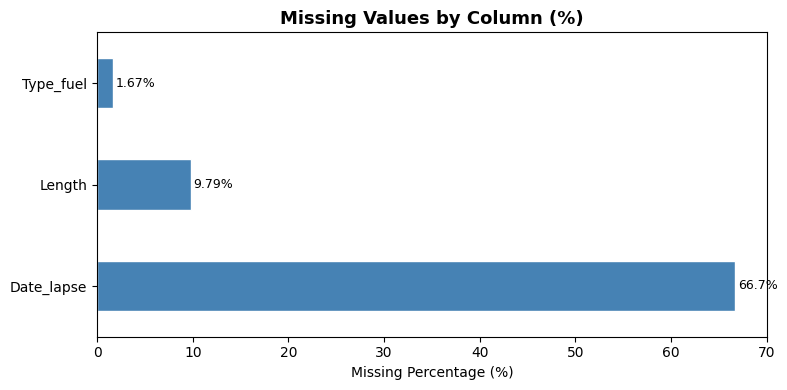

In [6]:
# Visualise missing data
fig, ax = plt.subplots(figsize=(8, 4))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Missing Values by Column (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Missing Percentage (%)')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Target Variable Analysis

In [7]:
# Create binary target: 1 if at least one claim, 0 otherwise
df['Claim_Occurred'] = (df['N_claims_year'] > 0).astype(int)

claim_counts = df['Claim_Occurred'].value_counts()
claim_pct    = df['Claim_Occurred'].value_counts(normalize=True) * 100

print("Target Variable – Claim_Occurred Distribution:")
print(pd.DataFrame({'Count': claim_counts, 'Percentage (%)': claim_pct.round(2)}))
print()
print(f"Class imbalance ratio  : {claim_counts[0] / claim_counts[1]:.2f}:1  (No Claim : Claim)")

Target Variable – Claim_Occurred Distribution:
                Count  Percentage (%)
Claim_Occurred                       
0               85909           81.39
1               19646           18.61

Class imbalance ratio  : 4.37:1  (No Claim : Claim)


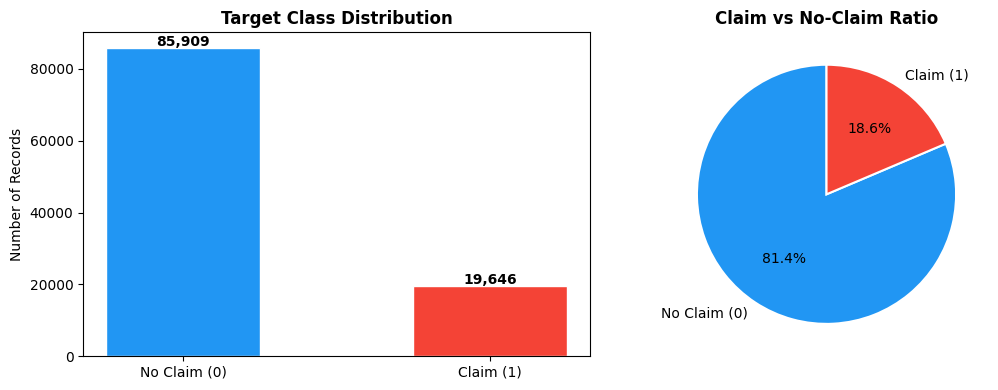

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
labels = ['No Claim (0)', 'Claim (1)']
colors = ['#2196F3', '#F44336']
bars = axes[0].bar(labels, claim_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Target Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Records')
for bar, val in zip(bars, claim_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(claim_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Claim vs No-Claim Ratio', fontweight='bold')

plt.tight_layout()
plt.show()


### Exploratory Data Visualisations

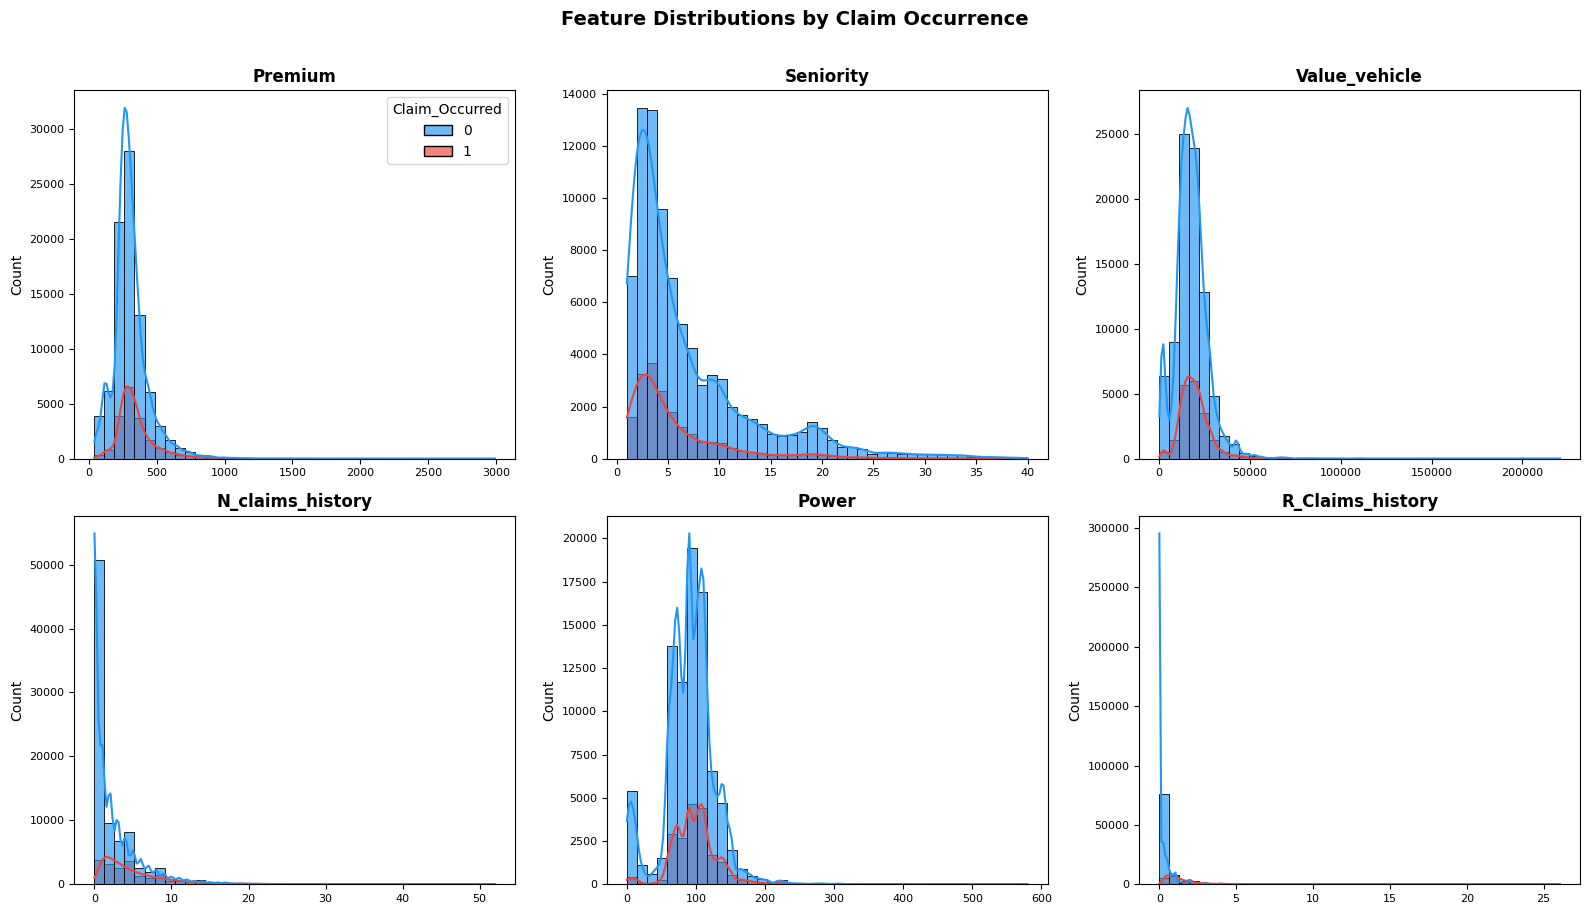

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Feature Distributions by Claim Occurrence', fontsize=14, fontweight='bold', y=1.01)

numeric_features = ['Premium', 'Seniority', 'Value_vehicle', 'N_claims_history', 'Power', 'R_Claims_history']
palette = {0: '#2196F3', 1: '#F44336'}

for ax, feat in zip(axes.flatten(), numeric_features):
    sns.histplot(data=df, x=feat, hue='Claim_Occurred', ax=ax,
                 bins=40, palette=palette, alpha=0.65, kde=True, legend=(feat == 'Premium'))
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

### Data Preprocessing

In [10]:
df_clean = df.copy()

In [11]:
# Parse date columns 
date_cols = ['Date_start_contract', 'Date_last_renewal',
             'Date_next_renewal', 'Date_birth', 'Date_driving_licence', 'Date_lapse']

for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], format='%d/%m/%Y', errors='coerce')

In [12]:
# Feature engineering
reference_date = pd.Timestamp('2020-01-01')   # approximate portfolio snapshot date

df_clean['Age_of_driver'] = ((reference_date - df_clean['Date_birth']).dt.days / 365.25).round(1)
df_clean['Driving_experience'] = ((reference_date - df_clean['Date_driving_licence']).dt.days / 365.25).round(1)
df_clean['Contract_duration'] = ((df_clean['Date_last_renewal'] - df_clean['Date_start_contract']).dt.days / 365.25).round(1)
df_clean['Vehicle_age'] = reference_date.year - df_clean['Year_matriculation']

In [13]:
# Drop columns
drop_cols = ['ID', 'Date_start_contract', 'Date_last_renewal', 'Date_next_renewal',
             'Date_birth', 'Date_driving_licence', 'Date_lapse',
             'Cost_claims_year',   # would cause data leakage
             'N_claims_year']      # source of target

df_clean.drop(columns=drop_cols, inplace=True)

In [14]:
# Handle missing values
print(f"\nMissing before imputation:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")

df_clean['Length'].fillna(df_clean['Length'].median(), inplace=True)
df_clean['Type_fuel'].fillna(df_clean['Type_fuel'].mode()[0], inplace=True)
df_clean['Age_of_driver'].fillna(df_clean['Age_of_driver'].median(), inplace=True)
df_clean['Driving_experience'].fillna(df_clean['Driving_experience'].median(), inplace=True)
df_clean['Contract_duration'].fillna(0, inplace=True)

print(f"\nMissing after imputation: {df_clean.isnull().sum().sum()} null values remaining")


Missing before imputation:
Type_fuel     1764
Length       10329
dtype: int64

Missing after imputation: 0 null values remaining


In [15]:
# Encode categorical
le = LabelEncoder()
df_clean['Type_fuel_enc'] = le.fit_transform(df_clean['Type_fuel'].astype(str))
df_clean.drop(columns=['Type_fuel'], inplace=True)
print(f"\nType_fuel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"\nFeature list ({len(df_clean.columns) - 1} features):")
features = [c for c in df_clean.columns if c != 'Claim_Occurred']
for i, f in enumerate(features, 1):
    print(f"  {i:2d}. {f}")



Type_fuel encoding: {'D': np.int64(0), 'P': np.int64(1)}

Final dataset shape: (105555, 26)

Feature list (25 features):
   1. Distribution_channel
   2. Seniority
   3. Policies_in_force
   4. Max_policies
   5. Max_products
   6. Lapse
   7. Payment
   8. Premium
   9. N_claims_history
  10. R_Claims_history
  11. Type_risk
  12. Area
  13. Second_driver
  14. Year_matriculation
  15. Power
  16. Cylinder_capacity
  17. Value_vehicle
  18. N_doors
  19. Length
  20. Weight
  21. Age_of_driver
  22. Driving_experience
  23. Contract_duration
  24. Vehicle_age
  25. Type_fuel_enc


### Train / Test Split

In [16]:
X = df_clean.drop(columns=['Claim_Occurred'])
y = df_clean['Claim_Occurred']

# Stratified 80/20 split preserves class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training set  : {X_train.shape[0]:,} rows | {X_train.shape[1]} features")
print(f"Test set      : {X_test.shape[0]:,} rows  | {X_test.shape[1]} features")

Training set  : 84,444 rows | 25 features
Test set      : 21,111 rows  | 25 features


### Class-Imbalance Handling (SMOTE)

In [17]:
print(f"\nTraining class distribution (before SMOTE):")
print(pd.Series(y_train).value_counts().to_string())

# Apply SMOTE only on TRAINING data to avoid data leakage
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nTraining class distribution (after SMOTE):")
print(pd.Series(y_train_bal).value_counts().to_string())
print(f"\nBalanced training set size: {X_train_bal.shape[0]:,}")



Training class distribution (before SMOTE):
Claim_Occurred
0    68727
1    15717

Training class distribution (after SMOTE):
Claim_Occurred
0    68727
1    68727

Balanced training set size: 137,454


### Model Training

In [18]:
rf_model = RandomForestClassifier(
    n_estimators      = 200,
    max_depth         = 15,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features      = 'sqrt',
    class_weight      = 'balanced',
    random_state      = SEED,
    n_jobs            = -1          # use all CPU cores
)

print(f"  Trees         : {rf_model.n_estimators}")
print(f"  Max depth     : {rf_model.max_depth}")
print(f"  Training rows : {X_train_bal.shape[0]:,}")
print()

rf_model.fit(X_train_bal, y_train_bal)


  Trees         : 200
  Max depth     : 15
  Training rows : 137,454



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### Model Evaluation

In [19]:
y_pred      = rf_model.predict(X_test)
y_pred_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
# Core metrics
acc       = accuracy_score(y_test, y_pred)
prec      = precision_score(y_test, y_pred)
rec       = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print(f"  Accuracy        : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision       : {prec:.4f}")
print(f"  Recall          : {rec:.4f}")
print(f"  F1 Score        : {f1:.4f}")
print(f"  ROC-AUC Score   : {roc_auc:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Claim', 'Claim']))


  Accuracy        : 0.9047  (90.47%)
  Precision       : 0.7066
  Recall          : 0.8343
  F1 Score        : 0.7652
  ROC-AUC Score   : 0.9599

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.96      0.92      0.94     17182
       Claim       0.71      0.83      0.77      3929

    accuracy                           0.90     21111
   macro avg       0.83      0.88      0.85     21111
weighted avg       0.91      0.90      0.91     21111



### Confusion Matrix & ROC Curve

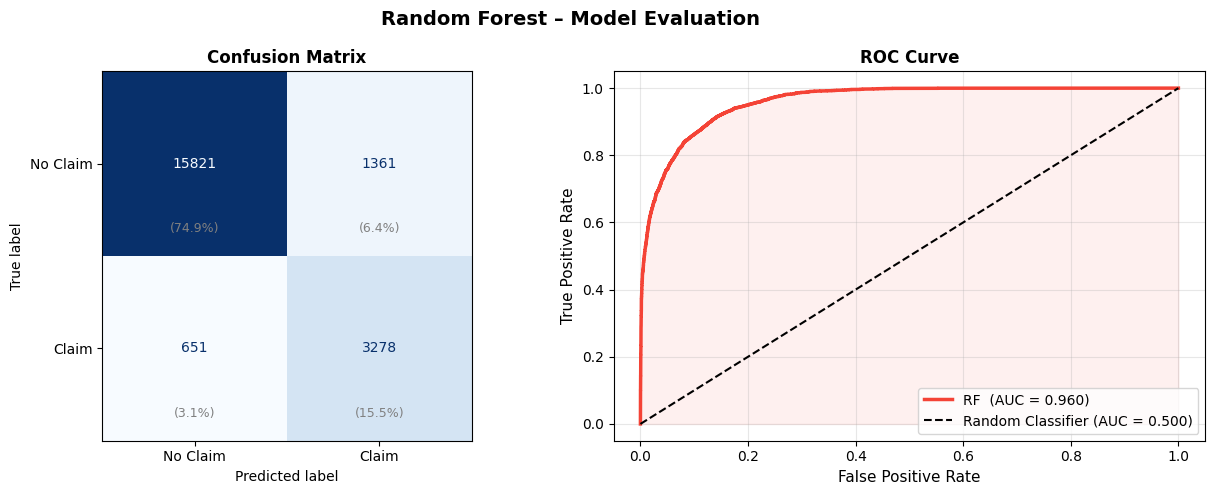

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Random Forest – Model Evaluation', fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Claim', 'Claim'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Annotate with percentages
total = cm.sum()
for i in range(2):
    for j in range(2):
        axes[0].text(j, i + 0.35, f'({cm[i,j]/total*100:.1f}%)',
                     ha='center', va='center', fontsize=9, color='grey')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#F44336', lw=2.5, label=f'RF  (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#F44336')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Stratified K-Fold Cross-Validation (k=5)

5-Fold Stratified Cross-Validation Results:
  Fold  Accuracy  F1 Score  ROC-AUC
Fold 1    0.8947    0.7522   0.9611
Fold 2    0.8995    0.7608   0.9622
Fold 3    0.8955    0.7556   0.9625
Fold 4    0.8984    0.7599   0.9619
Fold 5    0.8969    0.7569   0.9623

Mean Accuracy  : 0.8970  ± 0.0018
Mean F1 Score  : 0.7571  ± 0.0031
Mean ROC-AUC   : 0.9620  ± 0.0005


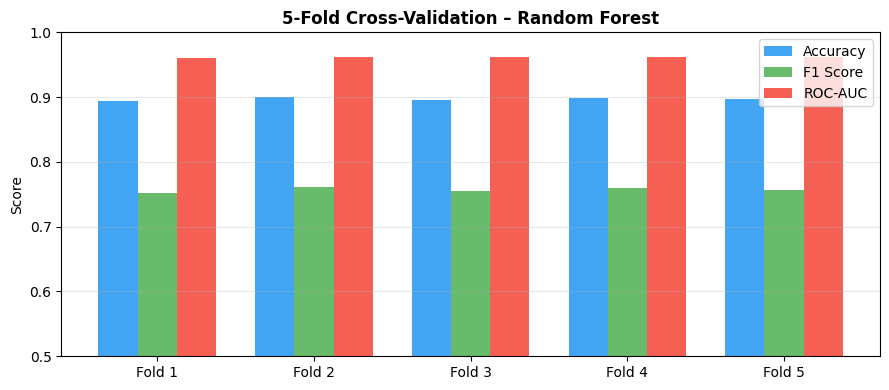

In [22]:
# Use original (unbalanced) data for CV to simulate real-world performance
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1  = cross_val_score(rf_model, X, y, cv=skf, scoring='f1',       n_jobs=-1)
cv_auc = cross_val_score(rf_model, X, y, cv=skf, scoring='roc_auc',  n_jobs=-1)
cv_acc = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

cv_results = pd.DataFrame({
    'Fold'    : [f'Fold {i+1}' for i in range(5)],
    'Accuracy': cv_acc.round(4),
    'F1 Score': cv_f1.round(4),
    'ROC-AUC' : cv_auc.round(4)
})

print("5-Fold Stratified Cross-Validation Results:")
print(cv_results.to_string(index=False))
print()
print(f"Mean Accuracy  : {cv_acc.mean():.4f}  ± {cv_acc.std():.4f}")
print(f"Mean F1 Score  : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}")
print(f"Mean ROC-AUC   : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}")

# Plot CV results
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(5)
width = 0.25
ax.bar(x - width, cv_acc,  width, label='Accuracy', color='#2196F3', alpha=0.85)
ax.bar(x,          cv_f1,  width, label='F1 Score',  color='#4CAF50', alpha=0.85)
ax.bar(x + width,  cv_auc, width, label='ROC-AUC',   color='#F44336', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_ylim(0.5, 1.0)
ax.set_title('5-Fold Cross-Validation – Random Forest', fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Feature Importance Analysis

Top 15 Most Important Features:
R_Claims_history      0.5076
N_claims_history      0.1775
Contract_duration     0.0938
Lapse                 0.0617
Seniority             0.0234
Premium               0.0127
Area                  0.0098
Driving_experience    0.0093
Max_policies          0.0092
Age_of_driver         0.0088
Policies_in_force     0.0084
Type_fuel_enc         0.0081
Value_vehicle         0.0076
Weight                0.0075
Year_matriculation    0.0073


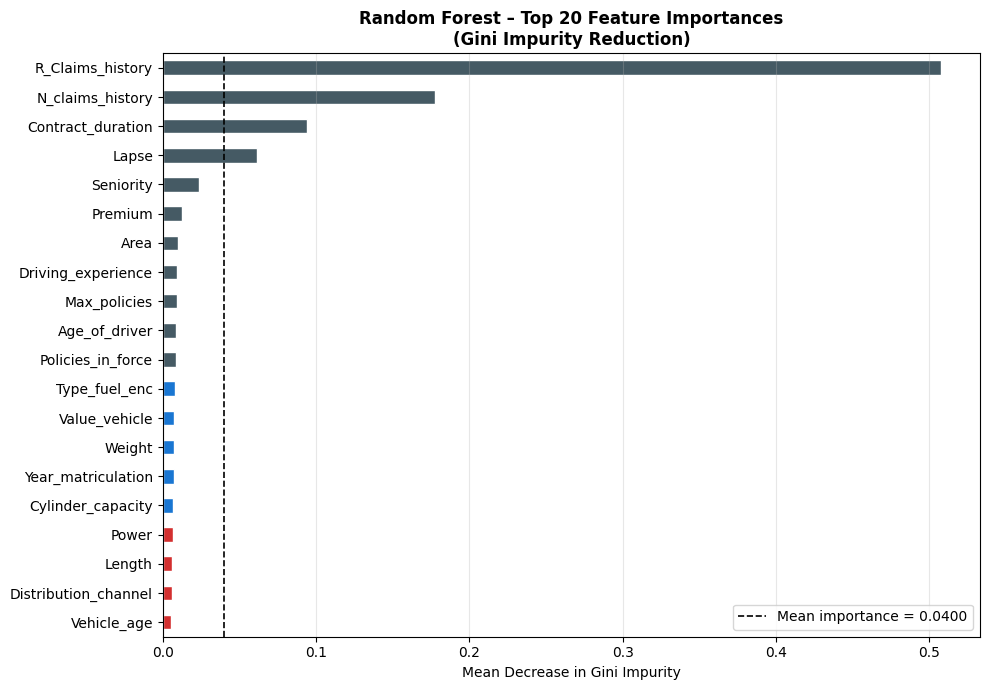

In [23]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=False)

print("Top 15 Most Important Features:")
print(importances_sorted.head(15).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
colors_fi = ['#D32F2F' if imp > importances_sorted.iloc[4] else
             '#1976D2' if imp > importances_sorted.iloc[9] else '#455A64'
             for imp in importances_sorted.values[:20]]

importances_sorted.head(20).plot(kind='barh', ax=ax, color=colors_fi[::-1], edgecolor='white')
ax.invert_yaxis()
ax.set_title('Random Forest – Top 20 Feature Importances\n(Gini Impurity Reduction)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.grid(axis='x', alpha=0.3)
ax.axvline(importances_sorted.mean(), color='black', linestyle='--', lw=1.2, label=f'Mean importance = {importances_sorted.mean():.4f}')
ax.legend()
plt.tight_layout()
plt.show()
